In [336]:
import pandas as pd 

df = pd.read_csv('data/rason_complete.csv')

In [337]:
import pandas as pd
import numpy as np


# ── Step 2: Flight metadata — one row per flight_id ─────────────────────────────
flight_meta = (
    df.groupby('flight_id')
    .agg(
        n_levels     = ('pressure_hPa',      'count'),
        burst_pres   = ('pressure_hPa',      'min'),
        max_height   = ('height_m',          'max'),
        min_temp     = ('temp_C',            'min'),
        mean_ascent  = ('ascent_rate_mps',   'mean'),
    )
    .reset_index()
)

# ── Step 3: 30 hPa threshold ─────────────────────────────────────────────────
flight_meta['premature'] = flight_meta['burst_pres'] > 30

print(flight_meta['premature'].value_counts())
print(f"\nTotal flights     : {len(flight_meta)}")
print(f"Nominal  (≤30  hPa): {(~flight_meta['premature']).sum()}")
print(f"Premature (>50 hPa): {flight_meta['premature'].sum()}")

# ── Step 4: Split raw df into premature and nominal ──────────────────────────
premature_ids = flight_meta.loc[flight_meta['premature'],  'flight_id']
nominal_ids   = flight_meta.loc[~flight_meta['premature'], 'flight_id']

df_premature = df[df['flight_id'].isin(premature_ids)].copy()
df_nominal   = df[df['flight_id'].isin(nominal_ids)].copy()

print(f"\nPremature rows : {len(df_premature)}")
print(f"Nominal rows   : {len(df_nominal)}")

premature
False    923
True     738
Name: count, dtype: int64

Total flights     : 1661
Nominal  (≤30  hPa): 923
Premature (>50 hPa): 738

Premature rows : 1263986
Nominal rows   : 2475555


In [338]:
# Select a random flight ID from the premature group
val_id = premature_ids.sample(2, random_state=44).iloc[0]

print(f"Validation Flight: {val_id}")


Validation Flight: 234


In [339]:
df_test = df_premature[df_premature['flight_id'] == val_id].copy()
df_test = df_test.drop(columns=['flight_id'])

df_premature = df_premature[df_premature['flight_id'] != val_id].copy()

In [340]:
print(df_premature.columns)

Index(['time_s', 'status_flag', 'pressure_hPa', 'height_m', 'lat_disp',
       'lon_disp', 'temp_C', 'dewpoint_C', 'wind_dir_deg', 'wind_speed_mps',
       'ascent_rate_mps', 'latitude', 'longitude', 'launch_time', 'flight_id',
       'hour'],
      dtype='str')


In [357]:
def engineer_features(flight_df):
    f = flight_df.sort_values('pressure_hPa', ascending=False).reset_index(drop=True)

    if len(f) < 3:
        return None

    for col in ['temp_C', 'dewpoint_C', 'wind_speed_mps',
                'height_m', 'ascent_rate_mps']:
        f[col] = pd.to_numeric(f[col], errors='coerce')
        f[col] = f[col].replace([-9999, -999, 9999, 99999], np.nan)

    f['dz']    = f['height_m'].diff().abs()
    f['dspd']  = f['wind_speed_mps'].diff().abs()
    f['dtemp'] = f['temp_C'].diff()
    dz_safe    = f['dz'].replace(0, np.nan)

    f['shear'] = np.where(f['dz'] > 10, f['dspd'] / dz_safe * 100, np.nan)

    g, Gamma_d = 9.81, 9.8 / 1000
    T_K = f['temp_C'] + 273.15
    N2  = (g / T_K) * (f['dtemp'] / dz_safe + Gamma_d)
    S2  = (f['dspd'] / dz_safe) ** 2
    f['Ri'] = N2 / S2.replace(0, np.nan)

    # ── dewpoint depression (spread) — key moisture diagnostic ───────────
    # Small spread = near-saturated air = balloon skin gets wet
    f['dd'] = f['temp_C'] - f['dewpoint_C']  # dewpoint depression (°C)
    # Relative humidity proxy from dewpoint depression
    # Magnus approximation: RH ≈ 100 - 5 * dd (valid for dd < 50°C)
    f['rh_approx'] = (100 - 5 * f['dd']).clip(0, 100)

    # ── ICING flag: supercooled liquid water zone ─────────────────────────
    # Requires sub-zero temperature AND near-saturation
    # Reference: GRUAN 2025 — ice formation on balloon membrane
    f['icing'] = (
        f['temp_C'].between(-20, 0) &
        (f['dd'].abs() < 3) &
        f['dewpoint_C'].notna()
    )

    # ── HEAVY MOISTURE flag: warm saturated layers ────────────────────────
    # Distinct from icing — positive temperature, near-saturated
    # Mechanism: liquid water collecting on latex skin weakens membrane
    # Reference: latex balloon science — prolonged moisture exposure
    # reduces tensile strength (BalloonHQ, Balloon Science 101)
    # Indonesia-specific: deep warm moist layer from maritime convection
    f['heavy_moisture'] = (
        f['temp_C'] > 0 &           # warm — NOT icing territory
        (f['dd'] < 2) &             # near-saturated (RH > ~90%)
        f['dewpoint_C'].notna()
    )

    # ascent rate stats
    ar         = f['ascent_rate_mps'].dropna()
    ar_mean    = ar.mean()
    ar_std     = ar.std() if len(ar) > 1 else np.nan
    burst_alt  = f['height_m'].max()
    near_burst = f[f['height_m'] >= (burst_alt - 2000)]['ascent_rate_mps'].dropna()

    spike_mask = (
        f['ascent_rate_mps'] > (ar_mean + 2 * ar_std)
        if (ar_std and ar_std > 0)
        else pd.Series([False] * len(f))
    )

    burst_pres    = f['pressure_hPa'].min()
    burst_idx     = f['pressure_hPa'].idxmin()
    temp_at_burst = f.loc[burst_idx, 'temp_C']

    shear_idx      = f['shear'].idxmax() if f['shear'].notna().any() else None
    max_shear      = f['shear'].max()
    shear_alt      = f.loc[shear_idx, 'height_m'] if shear_idx is not None else np.nan
    shear_to_burst = (burst_alt - shear_alt) if pd.notna(shear_alt) else np.nan
    boundary_layer_shear = f.loc[f['height_m'] <= 2000, 'shear'].max()

    ri_idx = f['Ri'].idxmin() if f['Ri'].notna().any() else None
    min_Ri = f['Ri'].min()
    ri_alt = f.loc[ri_idx, 'height_m'] if ri_idx is not None else np.nan

    # icing stats
    icing_levels = f[f['icing']]
    icing_depth  = len(icing_levels) * 50
    icing_index  = (
        icing_levels['temp_C'].abs() *
        icing_levels['dd'].abs()
    ).mean() if len(icing_levels) > 0 else 0.0

    # ── heavy moisture stats ──────────────────────────────────────────────
    moist_levels = f[f['heavy_moisture']]

    # depth of continuous warm saturated layer (m)
    moist_depth  = len(moist_levels) * 50

    # moisture burden index: integrate RH over the saturated depth
    # higher = more cumulative latex stress from moisture exposure
    moist_index  = (
        moist_levels['rh_approx'] *
        (moist_levels['dz'].fillna(50))       # layer thickness weight
    ).sum() if len(moist_levels) > 0 else 0.0

    # mean dewpoint depression in the saturated layer
    # smaller = more saturated = more skin wetting
    moist_dd_mean = moist_levels['dd'].mean() if len(moist_levels) > 0 else np.nan

    # column-integrated precipitable water proxy
    # integral of RH-approx over full profile (not just saturated layers)
    pw_proxy = (f['rh_approx'] * f['dz'].fillna(50)).sum()

    min_temp_idx = f['temp_C'].idxmin() if f['temp_C'].notna().any() else None
    min_temp     = f['temp_C'].min()
    min_temp_alt = f.loc[min_temp_idx, 'height_m'] if min_temp_idx is not None else np.nan

    # Reference: WMO CIMO Guide No. 8 - "Meteorological Instruments"
    # Prolonged volumetric expansion combined with UV exposure degrades latex.
    # A balloon that survives 110 minutes under tension is much more likely
    # to burst purely from material fatigue than a balloon at 45 minutes.
    time_to_burst_mins = len(f) * (1 / 60) if 'time_s' not in f.columns else (f['time_s'].max() - f['time_s'].min()) / 60

    return {
        'n_levels'              : len(f),
        'burst_pres_hpa'        : burst_pres,
        'burst_alt_m'           : burst_alt,
        'time_to_burst_mins'    : time_to_burst_mins,

        # wind shear
        'max_shear'             : max_shear,
        'shear_alt_m'           : shear_alt,
        'shear_to_burst_m'      : shear_to_burst,
        'bulk_shear_lower'      : f.loc[f['height_m'] <= 6000, 'shear'].mean(),
        'bulk_shear_upper'      : f.loc[f['height_m'] >  6000, 'shear'].mean(),
        'max_wind_speed_mps'    : f['wind_speed_mps'].max(),
        'boundary_layer_shear'  : boundary_layer_shear if pd.notna(boundary_layer_shear) else 0.0,

        # turbulence
        'ascent_rate_mean'      : ar_mean,
        'ascent_rate_std'       : ar_std,
        'ascent_rate_var_burst' : near_burst.std() if len(near_burst) > 1 else np.nan,
        'ascent_rate_max_spike' : f.loc[spike_mask, 'ascent_rate_mps'].max()
                                  if spike_mask.any() else 0.0,
        'n_turbulent_spikes'    : int(spike_mask.sum()),

        # Richardson
        'min_richardson'        : min_Ri,
        'ri_alt_m'              : ri_alt,
        'n_unstable_layers'     : int((f['Ri'] < 0.25).sum()),

        # icing (sub-zero, near-saturated)
        'icing_depth_m'         : icing_depth,
        'icing_index'           : icing_index,

        # heavy moisture (warm, near-saturated) 
        'moist_depth_m'         : moist_depth,
        'moist_index'           : moist_index,
        'moist_dd_mean'         : moist_dd_mean,
        'pw_proxy'              : pw_proxy,

        # cold tropopause
        'tropopause_temp_C'     : min_temp,
        'tropopause_alt_m'      : min_temp_alt,
        'temp_at_burst_C'       : temp_at_burst,


        'launch_time' : f['launch_time'].iloc[0]
    }


features_list = []
skipped = 0

for fid, group in df_premature.groupby('flight_id'):
    result = engineer_features(group)
    if result is not None:
        features_list.append(result)
    else:
        skipped += 1

feat_df = pd.DataFrame(features_list)
print(f"Processed : {len(feat_df)} flights")
print(f"Skipped   : {skipped}")
print(f"Shape     : {feat_df.shape}")

Processed : 737 flights
Skipped   : 0
Shape     : (737, 29)


In [359]:

def clean_features(df: pd.DataFrame) -> pd.DataFrame:
    feat_clean = df.copy()

    # Fill specific columns with 0
    for col in ['icing_index', 'bulk_shear_upper', 'ascent_rate_max_spike', 'n_turbulent_spikes']:
        if col in feat_clean.columns:
            feat_clean[col] = feat_clean[col].fillna(0)

    # temp_at_burst_C fallback
    if 'temp_at_burst_C' in feat_clean.columns and 'min_temp_C' in feat_clean.columns:
        feat_clean['temp_at_burst_C'] = feat_clean['temp_at_burst_C'].fillna(feat_clean['min_temp_C'])

    # Fill remaining numeric columns with median
    for col in feat_clean.select_dtypes(include=np.number).columns:
        feat_clean[col] = feat_clean[col].fillna(feat_clean[col].median())

    print("Remaining NaNs after cleaning:", feat_clean.isna().sum().sum())
    return feat_clean

feat_clean = clean_features(feat_df)

# ── Step 7: Scale + UMAP ──────────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler
import umap

feature_cols = [
    'burst_pres_hpa', 
    'max_shear', 'shear_alt_m', 'shear_to_burst_m',
    'max_wind_speed_mps', 'ascent_rate_mean', 'ascent_rate_std', 'ascent_rate_var_burst', 'ascent_rate_max_spike', 
    'n_turbulent_spikes','min_richardson', 'ri_alt_m', 'n_unstable_layers', 'boundary_layer_shear',
    'icing_depth_m', 'icing_index',
    'moist_depth_m', 'moist_index', 'moist_dd_mean', 'pw_proxy',
    'tropopause_temp_C', 'temp_at_burst_C', 'tropopause_alt_m' ]

X        = feat_clean[feature_cols].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Remaining NaNs after cleaning: 0


In [360]:
# ── Re-reduce to 5D specifically for clustering ──────────────────────────────
reducer_5d = umap.UMAP(
    n_components = 5,
    n_neighbors  = 20,   
    min_dist     = 0.0,
    random_state = 42
)
X_5d = reducer_5d.fit_transform(X_scaled)
print("5D UMAP done:", X_5d.shape)

# ── Test grid: both xi and dbscan methods ────────────────────────────────────
from sklearn.cluster import OPTICS

configs = [
    # method,   min_samples, min_cluster_size, xi,   eps
    ('xi',      15,          0.05,             0.05, None),
    ('xi',      25,          0.06,             0.01, None),
    ('xi',      25,          0.08,             0.01, None),
    ('xi',      25,          0.07,             0.08, None),
    ('xi',      15,          0.05,             0.08, None),
    ('xi',      20,          0.05,             0.08, None),
]

print(f"\n{'method':<8} {'min_s':<6} {'xi/eps':<8} {'clusters':<10} {'noise%':<8}")
print("─" * 44)

for method, min_s, min_cs, xi, eps in configs:
    kwargs = dict(
        min_samples      = min_s,
        min_cluster_size = min_cs,
        metric           = 'euclidean',
        cluster_method   = method,
    )
    if method == 'xi':
        kwargs['xi'] = xi
    else:
        kwargs['max_eps'] = eps

    try:
        lbl = OPTICS(**kwargs).fit_predict(X_5d)
        n_cl   = len(set(lbl)) - (1 if -1 in lbl else 0)
        noise  = (lbl == -1).mean() * 100
        marker = " ◄" if (5 <= n_cl <= 7 and noise < 35) else ""
        param  = xi if method == 'xi' else eps
        print(f"{method:<8} {min_s:<6} {param:<8} {n_cl:<10} {noise:.1f}%{marker}")
    except Exception as e:
        print(f"{method:<8} {min_s:<6} — error: {e}")

c:\Users\Asus\Ahlil\radiosonde_learning\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


5D UMAP done: (737, 5)

method   min_s  xi/eps   clusters   noise%  
────────────────────────────────────────────
xi       15     0.05     7          45.3%
xi       25     0.01     8          15.6%
xi       25     0.01     7          23.1% ◄
xi       25     0.08     4          4.1%
xi       15     0.08     4          3.8%
xi       20     0.08     4          65.9%


In [361]:
# ── Final clustering run ──────────────────────────────────────────────────────
from sklearn.cluster import OPTICS

clusterer = OPTICS(
    min_samples      = 25,
    min_cluster_size = 0.06,
    metric           = 'euclidean',
    cluster_method   = 'xi',
    xi               = 0.01
)
labels = clusterer.fit_predict(X_5d)
feat_clean['cluster'] = labels

print("Final cluster distribution:")
print(feat_clean['cluster'].value_counts().sort_index())
print(f"\nNoise (-1): {(labels == -1).sum()} flights "
      f"({(labels == -1).mean()*100:.1f}%)")

# ── Interpretation: mean feature profile per cluster ─────────────────────────
# These are the columns that carry physical meaning
interp_cols = [
    'burst_pres_hpa', 
    'max_shear', 'shear_alt_m', 'shear_to_burst_m',
     'max_wind_speed_mps',
    'ri_alt_m', 'n_unstable_layers',
    'icing_depth_m', 'icing_index', 'moist_index','moist_dd_mean',
    'tropopause_temp_C', 'tropopause_alt_m', 'temp_at_burst_C', 'pw_proxy',
]

overall_mean = feat_clean[interp_cols].mean()

print("\n" + "="*70)
print("CLUSTER PROFILES — deviation from overall premature mean")
print("="*70)

for c in sorted(feat_clean['cluster'].unique()):
    subset = feat_clean[feat_clean['cluster'] == c]
    label  = "NOISE" if c == -1 else f"Cluster {c}"
    print(f"\n{label}  (n={len(subset)})")
    print("-" * 50)

    cluster_mean = subset[interp_cols].mean()

    # compute % deviation from overall mean — highlights what's anomalous
    deviation = ((cluster_mean - overall_mean) / overall_mean.abs() * 100).round(1)

    # show top 6 most anomalous features (positive and negative)
    top_high = deviation.nlargest(4)
    top_low  = deviation.nsmallest(4)

    print("  HIGH (above premature average):")
    for feat, val in top_high.items():
        print(f"    {feat:<30} {cluster_mean[feat]:>8.2f}  ({val:+.0f}%)")

    print("  LOW (below premature average):")
    for feat, val in top_low.items():
        print(f"    {feat:<30} {cluster_mean[feat]:>8.2f}  ({val:+.0f}%)")

Final cluster distribution:
cluster
-1    115
 0     71
 1     95
 2     90
 3     70
 4    116
 5     55
 6     58
 7     67
Name: count, dtype: int64

Noise (-1): 115 flights (15.6%)

CLUSTER PROFILES — deviation from overall premature mean

NOISE  (n=115)
--------------------------------------------------
  HIGH (above premature average):
    ri_alt_m                        9935.77  (+65%)
    icing_index                       11.67  (+22%)
    icing_depth_m                   9486.52  (+8%)
    temp_at_burst_C                  -62.38  (+6%)
  LOW (below premature average):
    moist_dd_mean                      3.07  (-14%)
    max_wind_speed_mps                25.19  (-11%)
    max_shear                          4.75  (-9%)
    pw_proxy                       2092199.22  (-8%)

Cluster 0  (n=71)
--------------------------------------------------
  HIGH (above premature average):
    icing_depth_m                  16190.14  (+84%)
    shear_alt_m                    16298.42  (+30%)
 

In [345]:
from sklearn.mixture import GaussianMixture

# 1. Define the number of clusters (based on your OPTICS discovery, e.g., 6)
n_clusters = 7

# 2. Initialize and Fit the GMM on your 5D UMAP space
gmm = GaussianMixture(
    n_components=n_clusters, 
    covariance_type='full', 
    random_state=42
)
gmm.fit(X_5d)

# 3. Label your current data
feat_clean['cluster'] = gmm.predict(X_5d)

# 4. (Optional) Check the confidence of the labels
feat_clean['cluster_probs'] = np.max(gmm.predict_proba(X_5d), axis=1)

print("GMM Cluster distribution:")
print(feat_clean['cluster'].value_counts().sort_index())

GMM Cluster distribution:
cluster
0    121
1     62
2     95
3    168
4     61
5    136
6     94
Name: count, dtype: int64


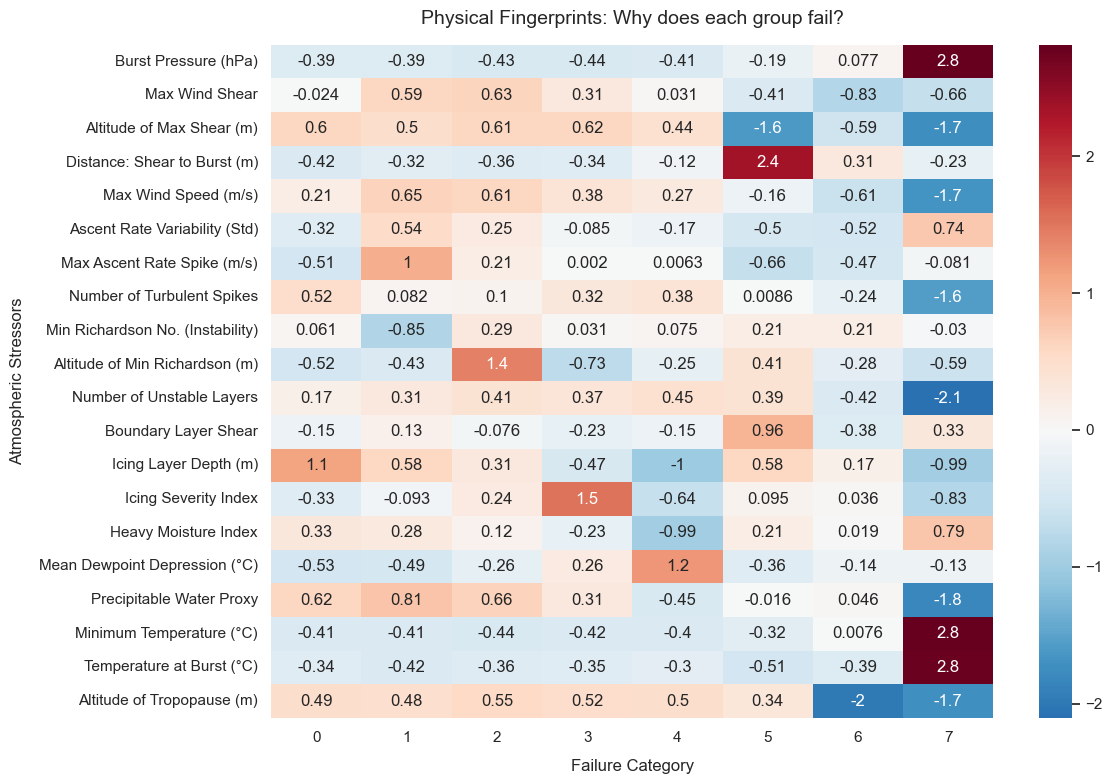

In [362]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define the clean labels (removed the dropped features for cleanliness)
feature_labels = {
    'burst_pres_hpa': 'Burst Pressure (hPa)',
    'burst_alt_m': 'Burst Altitude (m)',
    'max_shear': 'Max Wind Shear',
    'max_dir_shear': 'Max Directional Shear',
    'dir_shear_alt_m': 'Altitude of Max Dir Shear (m)',
    'max_speed_shear': 'Max Speed Shear',
    'shear_alt_m': 'Altitude of Max Shear (m)',
    'shear_to_burst_m': 'Distance: Shear to Burst (m)',
    'max_wind_speed_mps': 'Max Wind Speed (m/s)',
    'ascent_rate_std': 'Ascent Rate Variability (Std)',
    'ascent_rate_max_spike': 'Max Ascent Rate Spike (m/s)',
    'n_turbulent_spikes': 'Number of Turbulent Spikes',
    'min_richardson': 'Min Richardson No. (Instability)',
    'boundary_layer_shear': 'Boundary Layer Shear',
    'ri_alt_m': 'Altitude of Min Richardson (m)',
    'n_unstable_layers': 'Number of Unstable Layers',
    'icing_depth_m': 'Icing Layer Depth (m)',
    'icing_index': 'Icing Severity Index',
    'moist_index': 'Heavy Moisture Index',
    'moist_dd_mean': 'Mean Dewpoint Depression (°C)',
    'pw_proxy': 'Precipitable Water Proxy',
    'tropopause_temp_C': 'Minimum Temperature (°C)',
    'tropopause_alt_m': 'Altitude of Tropopause (m)',
    'temp_at_burst_C': 'Temperature at Burst (°C)',
}

# 2. Calculate the Z-Scores normally (so the math doesn't shift)
cluster_profile = feat_clean.groupby('cluster')[feature_cols].mean()
cluster_z_scores = (cluster_profile - feat_clean[feature_cols].mean()) / feat_clean[feature_cols].std()

# --- THE FILTERING STEP ---
# Drop the noise cluster (-1) from the rows
if -1 in cluster_z_scores.index:
    cluster_z_scores = cluster_z_scores.drop(index=-1)

# Drop the insignificant features from the columns
features_to_drop = [
    'bulk_shear_lower', 
    'bulk_shear_upper', 
    'ascent_rate_var_burst', 
    'ascent_rate_mean', 
    'moist_depth_m'
]
cluster_z_scores = cluster_z_scores.drop(columns=features_to_drop, errors='ignore')
# --------------------------

# 3. Transpose the matrix and rename the index
plot_data = cluster_z_scores.T.rename(index=feature_labels)

# 4. Plot the Heatmap
plt.figure(figsize=(12, 8)) # Made slightly more compact since we removed features
sns.heatmap(plot_data, cmap='RdBu_r', annot=True, center=0)

plt.title("Physical Fingerprints: Why does each group fail?", pad=15, fontsize=14)
plt.ylabel("Atmospheric Stressors", labelpad=10, fontsize=12)
plt.xlabel("Failure Category", labelpad=10, fontsize=12)

# Make the y-axis labels horizontal
plt.yticks(rotation=0) 
plt.tight_layout()
plt.show()

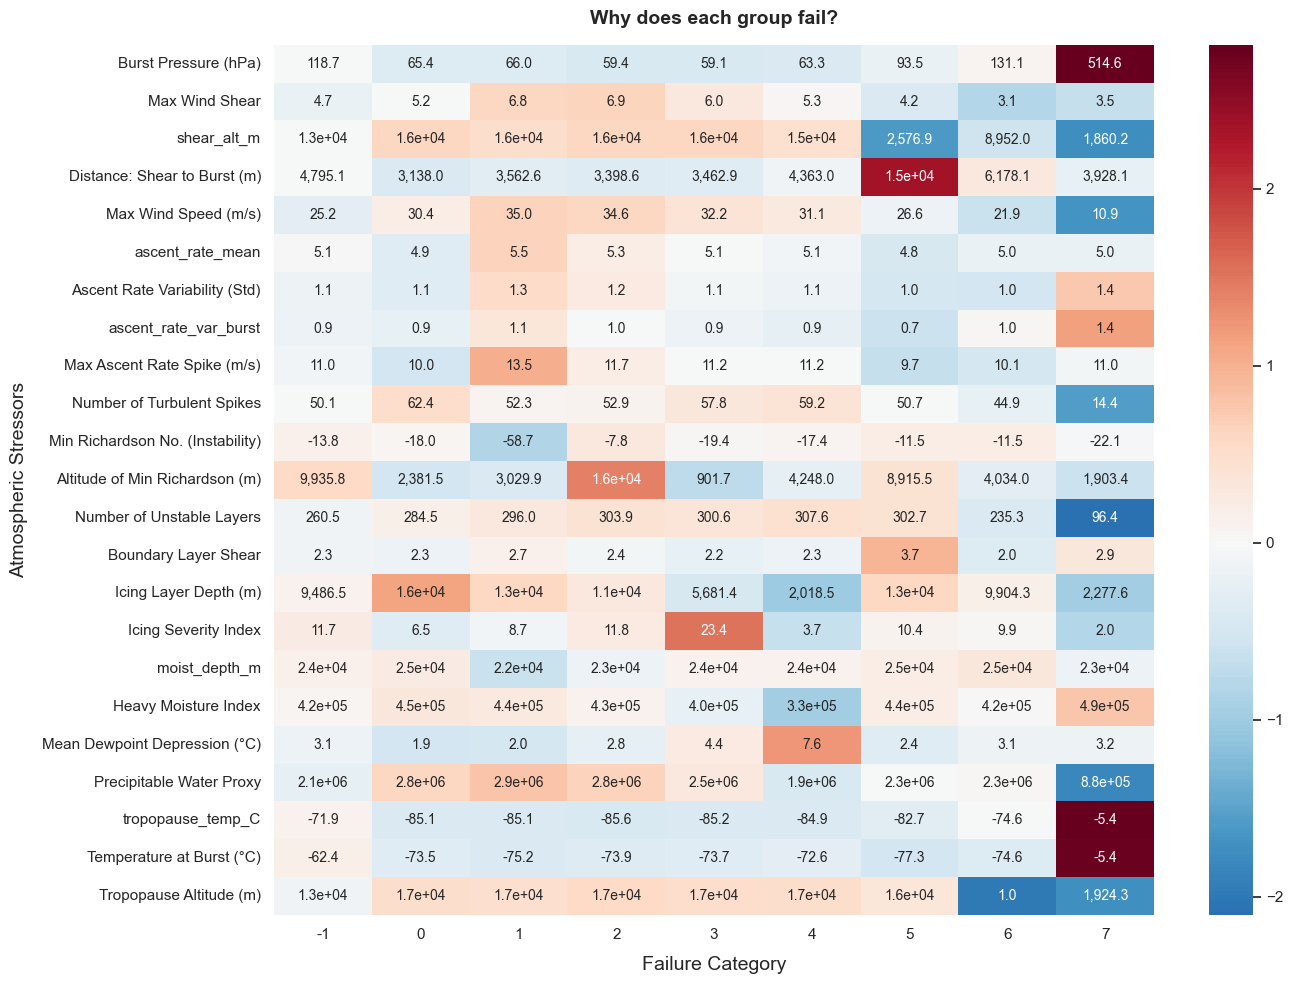

In [363]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. Define the clean labels (UPDATED to match your new features!)
feature_labels = {
    'burst_pres_hpa': 'Burst Pressure (hPa)',
    'burst_alt_m': 'Burst Altitude (m)',
    'max_shear': 'Max Wind Shear',
    'Altitude of Max Shear (m)': 'Altitude of Max Shear (m)', # Already clean in your DF
    'shear_to_burst_m': 'Distance: Shear to Burst (m)',
    'max_wind_speed_mps': 'Max Wind Speed (m/s)',
    'ascent_rate_std': 'Ascent Rate Variability (Std)',
    'ascent_rate_max_spike': 'Max Ascent Rate Spike (m/s)',
    'n_turbulent_spikes': 'Number of Turbulent Spikes',
    'min_richardson': 'Min Richardson No. (Instability)',
    'ri_alt_m': 'Altitude of Min Richardson (m)',
    'n_unstable_layers': 'Number of Unstable Layers',
    'boundary_layer_shear': 'Boundary Layer Shear',          # NEW
    'icing_depth_m': 'Icing Layer Depth (m)',
    'icing_index': 'Icing Severity Index',
    'moist_index': 'Heavy Moisture Index',
    'moist_dd_mean': 'Mean Dewpoint Depression (°C)',
    'pw_proxy': 'Precipitable Water Proxy',
    'min_temp_C': 'Minimum Temperature (°C)',
    'temp_at_burst_C': 'Temperature at Burst (°C)',
    'tropopause_alt_m': 'Tropopause Altitude (m)',           # NEW
    'time_to_burst_mins': 'Time Under Tension (mins)',       # NEW
}

# 2. Calculate BOTH raw means (for text) and Z-Scores (for colors)
cluster_profile_raw = feat_clean.groupby('cluster')[feature_cols].mean()
cluster_z_scores = (cluster_profile_raw - feat_clean[feature_cols].mean()) / feat_clean[feature_cols].std()

# --- THE FILTERING STEP ---
#if -1 in cluster_z_scores.index:
#    cluster_z_scores = cluster_z_scores.drop(index=-1)
#    cluster_profile_raw = cluster_profile_raw.drop(index=-1)

# 3. Transpose both matrices and rename the index
plot_data_z = cluster_z_scores.T.rename(index=feature_labels)
plot_data_raw = cluster_profile_raw.T.rename(index=feature_labels)

# --- THE FORMATTING FIX ---
def format_text(x):
    if pd.isna(x):
        return ""
    if abs(x) > 9999:
        # If the number exploded (like Richardson), use scientific notation (e.g., 1.6e+16)
        # Or alternatively, cap it with: return "> 9999"
        return f"{x:.1e}" 
    return f"{x:,.1f}"

# Apply the smart formatter instead of the blind lambda
annot_labels = plot_data_raw.map(format_text)
# --------------------------

# 4. Plot the Heatmap
plt.figure(figsize=(14, 10)) # Made slightly larger to accommodate all rows comfortably

sns.heatmap(data=plot_data_z, 
            annot=annot_labels, 
            fmt='', 
            cmap='RdBu_r', 
            center=0,
            annot_kws={"size": 10}) # Slightly shrink font size to ensure it fits the boxes

plt.title("Why does each group fail?", pad=15, fontsize=14, fontweight='bold')
plt.ylabel("Atmospheric Stressors", labelpad=10, fontsize=14)
plt.xlabel("Failure Category", labelpad=10, fontsize=14)

plt.yticks(rotation=0) 
plt.tight_layout()
plt.show()

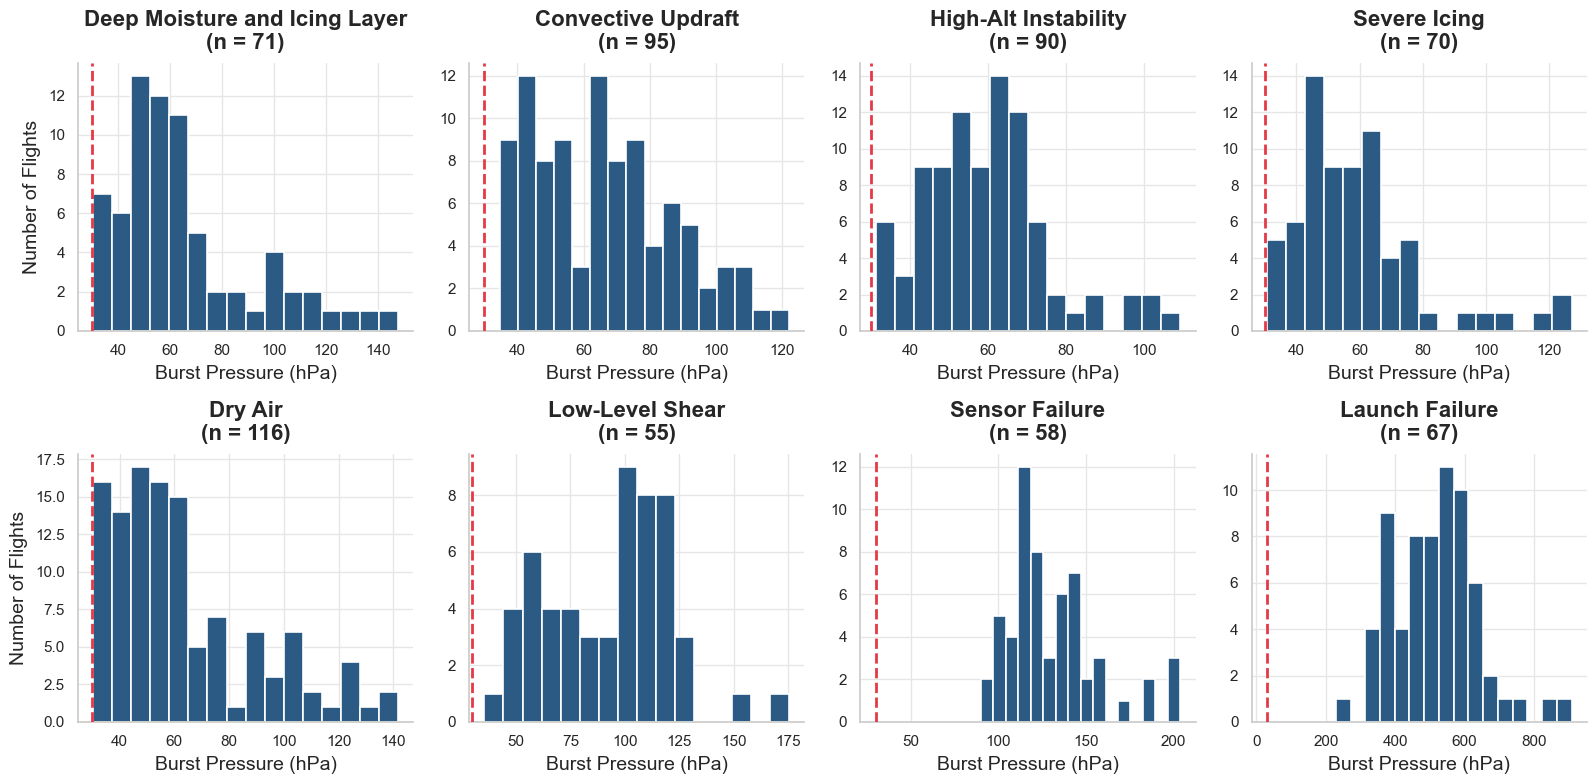

In [364]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Set a clean, modern style for presentations
sns.set_theme(style="whitegrid", rc={"axes.edgecolor": "0.8", "grid.color": "0.9"})

# 2. Map the cluster numbers back to their physical meaning!
# Update these based on your final combined classes (e.g., merged icing)
cluster_names = {
    0: 'Deep Moisture and Icing Layer',
    1: 'Convective Updraft',
    2: 'High-Alt Instability',
    3: 'Severe Icing',
    4: 'Dry Air',
    5: 'Low-Level Shear',
    6: 'Sensor Failure',
    7: 'Launch Failure'
}

valid_clusters = sorted([c for c in feat_clean['cluster'].unique() if c != -1])

# Make the figure slightly wider to accommodate text
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, c in enumerate(valid_clusters):
    sub = feat_clean[feat_clean['cluster'] == c]
    ax = axes[i]
    
    # Use a professional corporate blue and thicker edges for the bars
    ax.hist(sub['burst_pres_hpa'], bins=16, color='#2B5B84', edgecolor='white', linewidth=1.2)
    
    # Add human-readable titles with the sample size on a new line
    title_name = cluster_names.get(c, f"Cluster {c}")
    ax.set_title(f"{title_name}\n(n = {len(sub)})", fontsize=16, fontweight='bold', pad=10)
    
    ax.set_xlabel('Burst Pressure (hPa)', fontsize=14, labelpad=5)
    
    # Only show the Y-axis label on the far left charts to reduce clutter
    if i % 4 == 0:
        ax.set_ylabel('Number of Flights', fontsize=14, labelpad=5)
    
    # Format the Target Line
    ax.axvline(30, color='#E63946', linewidth=2, linestyle='--', zorder=3)
    
    # Annotate the red line on the first chart so the audience knows what it is
    if i == 0:
        # Get the max Y value to place the text nicely near the top
        y_max = ax.get_ylim()[1]

    # Remove the top and right borders (Chart Junk)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Hide any completely empty subplots (e.g., if you only have 7 valid clusters, the 8th box is blank)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

# Add a compelling overarching title

plt.tight_layout()

# Save at 300 DPI (Standard for sharp PowerPoint images)
plt.savefig('burst_pressure_presentation.png', dpi=300, bbox_inches='tight')
plt.show()

In [365]:
label_map = {
    -1 : 'unknown_premature',   # exclude from training
     0 : 'deep_moisture_icing',
     1 : 'high_updraft',
     2 : 'atmospheric_instability',
     3 : 'severe_icing',
     4 : 'dry_layer',
     5 : 'wind_shear',
     6 : 'sensor_failure',
     7 : 'launch_failure'
}
feat_clean['cause'] = feat_clean['cluster'].map(label_map)

# ── CREATE FINAL TRAINING DATASET ────────────────────────────────────────────
# Just drop the unknown noise. No nominal data needed!
train_df = feat_clean[feat_clean['cause'] != 'unknown_premature'].copy()

print("\nFinal training dataset (Premature ONLY):")
print(train_df['cause'].value_counts())
print(f"\nTotal: {len(train_df)} flights")


Final training dataset (Premature ONLY):
cause
dry_layer                  116
high_updraft                95
atmospheric_instability     90
deep_moisture_icing         71
severe_icing                70
launch_failure              67
sensor_failure              58
wind_shear                  55
Name: count, dtype: int64

Total: 622 flights


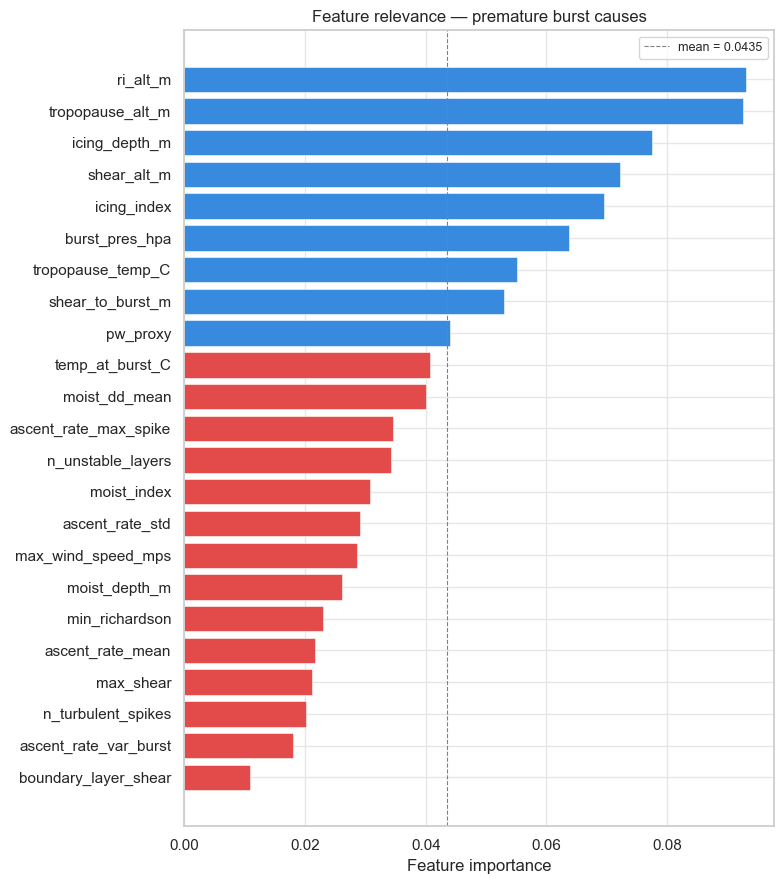

Features BELOW mean importance (consider dropping):
  boundary_layer_shear           0.0109
  ascent_rate_var_burst          0.0180
  n_turbulent_spikes             0.0201
  max_shear                      0.0212
  ascent_rate_mean               0.0217
  min_richardson                 0.0230
  moist_depth_m                  0.0261
  max_wind_speed_mps             0.0286
  ascent_rate_std                0.0291
  moist_index                    0.0308
  n_unstable_layers              0.0343
  ascent_rate_max_spike          0.0345
  moist_dd_mean                  0.0400
  temp_at_burst_C                0.0407


In [367]:
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

feature_cols_final = [
  'burst_pres_hpa', 
    'max_shear', 'shear_alt_m', 'shear_to_burst_m',
    'max_wind_speed_mps', 'ascent_rate_mean', 'ascent_rate_std', 'ascent_rate_var_burst', 'ascent_rate_max_spike', 
    'n_turbulent_spikes','min_richardson', 'ri_alt_m', 'n_unstable_layers', 'boundary_layer_shear',
    'icing_depth_m', 'icing_index',
    'moist_depth_m', 'moist_index', 'moist_dd_mean', 'pw_proxy',
    'tropopause_temp_C', 'temp_at_burst_C', 'tropopause_alt_m']

X_imp = train_df[feature_cols_final].fillna(0).values
y_imp = train_df['cause'].values

rf_imp = RandomForestClassifier(
    n_estimators  = 300,
    class_weight  = 'balanced',
    random_state  = 42,
    n_jobs        = -1
)
rf_imp.fit(X_imp, y_imp)

importance_df = pd.DataFrame({
    'feature'    : feature_cols_final,
    'importance' : rf_imp.feature_importances_
}).sort_values('importance', ascending=True)

mean_imp = importance_df['importance'].mean()

fig, ax = plt.subplots(figsize=(8, 9))
colors = ['#E24B4A' if v < mean_imp else '#378ADD'
          for v in importance_df['importance']]
ax.barh(importance_df['feature'], importance_df['importance'],
        color=colors, edgecolor='white', linewidth=0.4)
ax.axvline(mean_imp, color='gray', linestyle='--',
           linewidth=0.8, label=f'mean = {mean_imp:.4f}')
ax.set_xlabel('Feature importance')
ax.set_title('Feature relevance — premature burst causes')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

below_mean = importance_df[importance_df['importance'] < mean_imp]['feature'].tolist()
print("Features BELOW mean importance (consider dropping):")
for f in below_mean:
    val = importance_df.loc[importance_df['feature']==f, 'importance'].values[0]
    print(f"  {f:<30} {val:.4f}")

Classes: ['atmospheric_instability', 'deep_moisture_icing', 'dry_layer', 'high_updraft', 'launch_failure', 'sensor_failure', 'severe_icing', 'wind_shear']
Class distribution:
  atmospheric_instability        90
  deep_moisture_icing            71
  dry_layer                      116
  high_updraft                   95
  launch_failure                 67
  sensor_failure                 58
  severe_icing                   70
  wind_shear                     55

5-fold CV  F1 (weighted): 0.890 ± 0.015
Per-fold scores: [0.916 0.89  0.871 0.878 0.893]

Train: 497 flights | Test: 125 flights
Test class distribution:
  atmospheric_instability        18
  deep_moisture_icing            3
  dry_layer                      35
  high_updraft                   23
  launch_failure                 9
  sensor_failure                 13
  severe_icing                   16
  wind_shear                     8


c:\Users\Asus\Ahlil\radiosonde_learning\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [17:08:39] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Classification report:
                         precision    recall  f1-score   support

atmospheric_instability       0.89      0.94      0.92        18
    deep_moisture_icing       0.75      1.00      0.86         3
              dry_layer       0.94      0.91      0.93        35
           high_updraft       0.95      0.87      0.91        23
         launch_failure       1.00      1.00      1.00         9
         sensor_failure       0.87      1.00      0.93        13
           severe_icing       0.88      0.94      0.91        16
             wind_shear       1.00      0.75      0.86         8

               accuracy                           0.92       125
              macro avg       0.91      0.93      0.91       125
           weighted avg       0.92      0.92      0.92       125



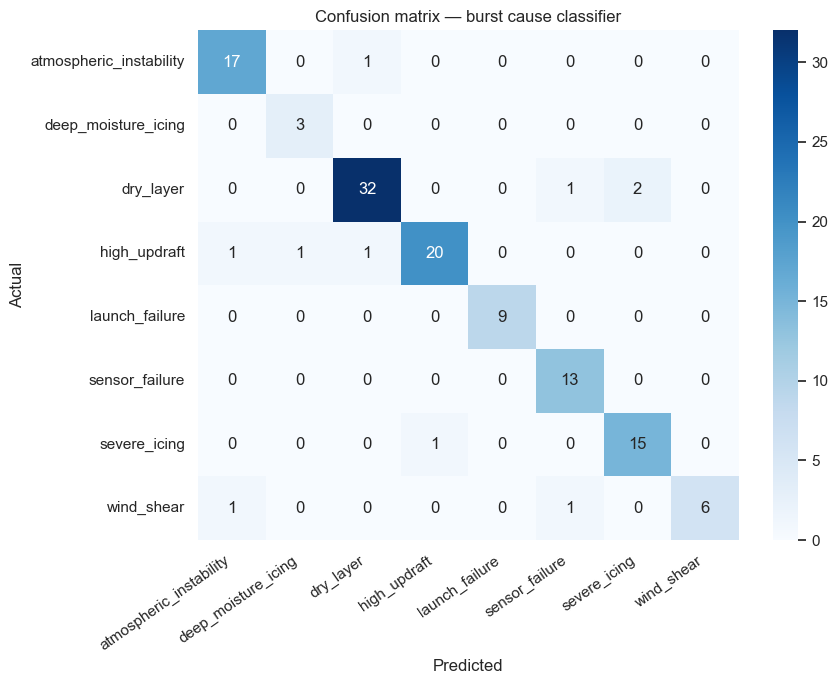

In [368]:
import joblib
import os
from sklearn.preprocessing import StandardScaler, LabelEncoder
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

os.makedirs('models', exist_ok=True)

# ── Encode labels ─────────────────────────────────────────────────────────────
le = LabelEncoder()
y_all = le.fit_transform(train_df['cause'].values)
X_all = train_df[feature_cols].fillna(0).values

print("Classes:", list(le.classes_))
print("Class distribution:")
for cls, count in zip(*np.unique(le.inverse_transform(y_all),
                                  return_counts=True)):
    print(f"  {cls:<30} {count}")

# ── Scale ─────────────────────────────────────────────────────────────────────
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_all)

# ── 5-fold cross-validation ───────────────────────────────────────────────────
# Use stratified k-fold to preserve class proportions in each fold
clf_cv = XGBClassifier(
    n_estimators      = 300,
    max_depth         = 5,
    learning_rate     = 0.05,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    use_label_encoder = False,
    eval_metric       = 'mlogloss',
    random_state      = 42,
    n_jobs            = -1,
)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(clf_cv, X_scaled, y_all,
                             cv=cv, scoring='f1_weighted', n_jobs=-1)
print(f"\n5-fold CV  F1 (weighted): {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
print(f"Per-fold scores: {np.round(cv_scores, 3)}")

# ── Time-based hold-out test split ────────────────────────────────────────────
# Sort by launch_time so the test set is always the most recent flights
# This avoids data leakage from future → past
train_sorted = train_df.sort_values('launch_time').reset_index(drop=True)
split_idx    = int(len(train_sorted) * 0.8)
train_set    = train_sorted.iloc[:split_idx]
test_set     = train_sorted.iloc[split_idx:]

X_tr = scaler.transform(train_set[feature_cols_final].fillna(0).values)
X_te = scaler.transform(test_set[feature_cols_final].fillna(0).values)
y_tr = le.transform(train_set['cause'].values)
y_te = le.transform(test_set['cause'].values)

print(f"\nTrain: {len(train_set)} flights | Test: {len(test_set)} flights")
print("Test class distribution:")
for cls, count in zip(*np.unique(le.inverse_transform(y_te),
                                  return_counts=True)):
    print(f"  {cls:<30} {count}")

# ── Train on 80% ──────────────────────────────────────────────────────────────
clf_eval = XGBClassifier(
    n_estimators      = 400,
    max_depth         = 5,
    learning_rate     = 0.05,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    use_label_encoder = False,
    eval_metric       = 'mlogloss',
    random_state      = 42,
    n_jobs            = -1,
)
clf_eval.fit(X_tr, y_tr,
             eval_set=[(X_te, y_te)],
             verbose=False)

# ── Evaluation report ─────────────────────────────────────────────────────────
y_pred = clf_eval.predict(X_te)
print("\nClassification report:")
print(classification_report(y_te, y_pred,
                             target_names=le.classes_,
                             zero_division=0))

# ── Confusion matrix ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))
cm = confusion_matrix(y_te, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion matrix — burst cause classifier')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [369]:
# ── Refit on ALL labeled data before saving ───────────────────────────────────
# Always refit on the full dataset — the eval model above was only on 80%
clf_final = XGBClassifier(
    n_estimators      = 400,
    max_depth         = 5,
    learning_rate     = 0.05,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    use_label_encoder = False,
    eval_metric       = 'mlogloss',
    random_state      = 42,
    n_jobs            = -1,
)
clf_final.fit(X_scaled, y_all)

# ── Save ──────────────────────────────────────────────────────────────────────
joblib.dump(clf_final,          'models/burst_classifier_model.joblib')
joblib.dump(scaler,             'models/burst_classifier_scaler.joblib')
joblib.dump(le,                 'models/burst_label_encoder.joblib')
joblib.dump(feature_cols_final, 'models/feature_cols.joblib')
joblib.dump(label_map,          'models/label_map.joblib')

print("Saved to models/:")
for f in os.listdir('models'):
    size = os.path.getsize(f'models/{f}') / 1024
    print(f"  {f:<45} {size:.1f} KB")

# ── Quick sanity check: predict on a few training samples ────────────────────
sample = train_df.sample(5, random_state=42)
X_sample = scaler.transform(sample[feature_cols_final].fillna(0).values)
preds    = le.inverse_transform(clf_final.predict(X_sample))
probs    = clf_final.predict_proba(X_sample).max(axis=1)

print("\nSanity check — 5 random training flights:")
print(f"{'Actual':<30} {'Predicted':<30} {'Confidence'}")
print("-" * 70)
for actual, pred, prob in zip(sample['cause'].values, preds, probs):
    match = "OK" if actual == pred else "MISMATCH"
    print(f"{actual:<30} {pred:<30} {prob:.1%}  {match}")

c:\Users\Asus\Ahlil\radiosonde_learning\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [17:09:23] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Saved to models/:
  burst_classifier_model.joblib                 3022.2 KB
  burst_classifier_scaler.joblib                1.1 KB
  burst_label_encoder.joblib                    0.6 KB
  feature_cols.joblib                           0.4 KB
  label_map.joblib                              0.2 KB

Sanity check — 5 random training flights:
Actual                         Predicted                      Confidence
----------------------------------------------------------------------
deep_moisture_icing            deep_moisture_icing            99.6%  OK
atmospheric_instability        atmospheric_instability        99.8%  OK
high_updraft                   high_updraft                   99.0%  OK
atmospheric_instability        atmospheric_instability        99.3%  OK
launch_failure                 launch_failure                 99.5%  OK
